In [1]:
import pandas as pd

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df= pd.read_csv('heart_failure_clinical_records_dataset.csv')

In [4]:
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


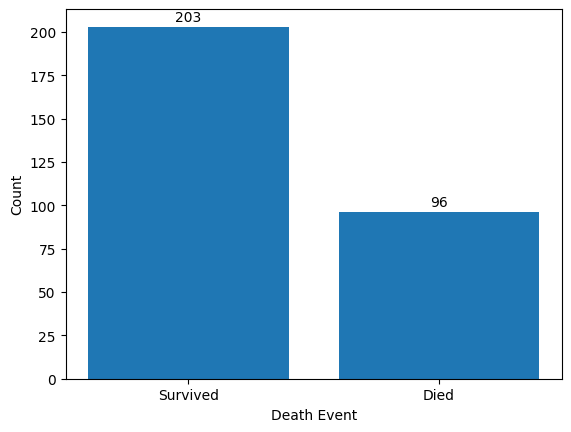

In [5]:
bars = plt.bar(df['DEATH_EVENT'].value_counts().index, df['DEATH_EVENT'].value_counts().values,tick_label=['Survived','Died'])
plt.xlabel('Death Event')
plt.ylabel('Count')
plt.gca().bar_label(bars, padding=2)
plt.show()

In [6]:
df['DEATH_EVENT'].value_counts()

DEATH_EVENT
0    203
1     96
Name: count, dtype: int64

C:\Users\yazee\AppData\Local\Temp\ipykernel_28852\3880666505.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(df['age'], labels=['Age'])


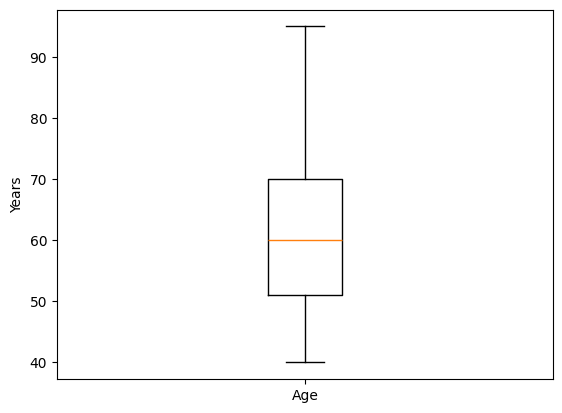

In [7]:
plt.boxplot(df['age'], labels=['Age'])
plt.ylabel('Years')
plt.show()

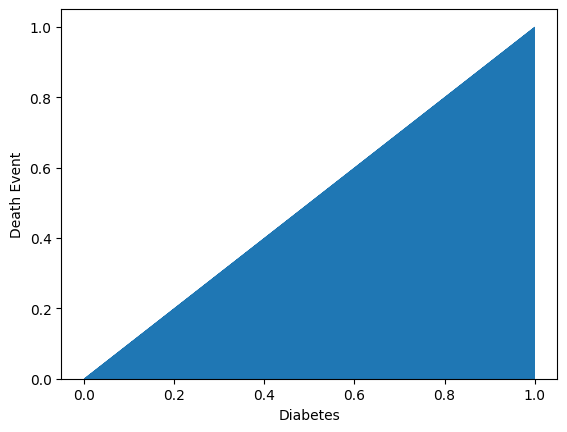

In [8]:
plt.stackplot(df['diabetes'], df['DEATH_EVENT'])
plt.xlabel('Diabetes')
plt.ylabel('Death Event')
plt.show()

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


In [12]:
negative_age = df[df['age']<0]
print(negative_age)

Empty DataFrame
Columns: [age, anaemia, creatinine_phosphokinase, diabetes, ejection_fraction, high_blood_pressure, platelets, serum_creatinine, serum_sodium, sex, smoking, time, DEATH_EVENT]
Index: []


In [13]:
X=df.drop('DEATH_EVENT', axis=1)
y=df['DEATH_EVENT']

In [14]:

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [15]:
from sklearn import naive_bayes
model = naive_bayes.GaussianNB()
model.fit(X_train, y_train)
predictions = model.predict(X_test)


Accuracy of the model is:  0.7333333333333333
Recall of the model is:  0.4
Precision of the model is:  0.9090909090909091
F1 score of the model is:  0.5555555555555556


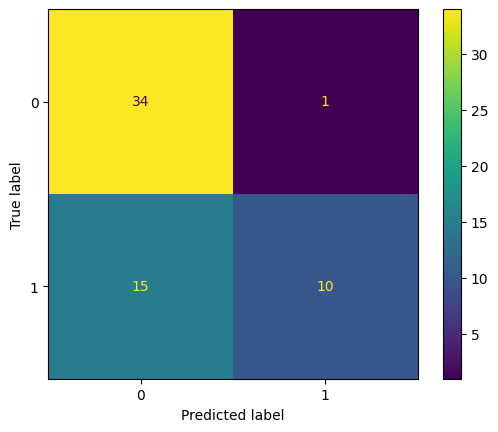

In [16]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
accuracy = accuracy_score(y_test, predictions)
recall = recall_score(y_test, predictions)
precision = precision_score(y_test, predictions)
f1 = f1_score(y_test, predictions)
print("Accuracy of the model is: ", accuracy)
print("Recall of the model is: ", recall)
print("Precision of the model is: ", precision)
print("F1 score of the model is: ", f1)

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)
probabilities = model.predict_proba(X_test_scaled)[:, 1]
custom_threshold = 0.1
predictions = (probabilities >= custom_threshold).astype(int)

Accuracy of the model is:  0.7
Recall of the model is:  0.92
Precision of the model is:  0.5897435897435898
F1 score of the model is:  0.71875


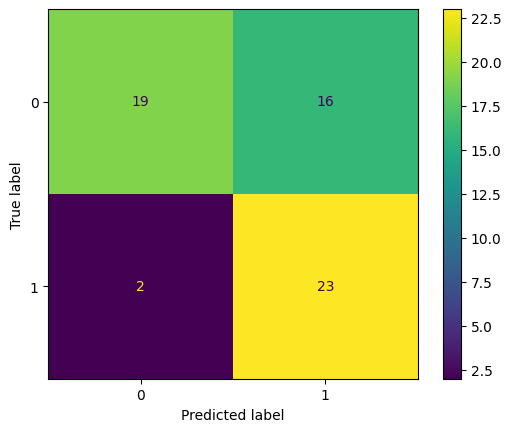

In [18]:
cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
accuracy = accuracy_score(y_test, predictions)
recall = recall_score(y_test, predictions)
precision = precision_score(y_test, predictions)
f1 = f1_score(y_test, predictions)
print("Accuracy of the model is: ", accuracy)
print("Recall of the model is: ", recall)
print("Precision of the model is: ", precision)
print("F1 score of the model is: ", f1)

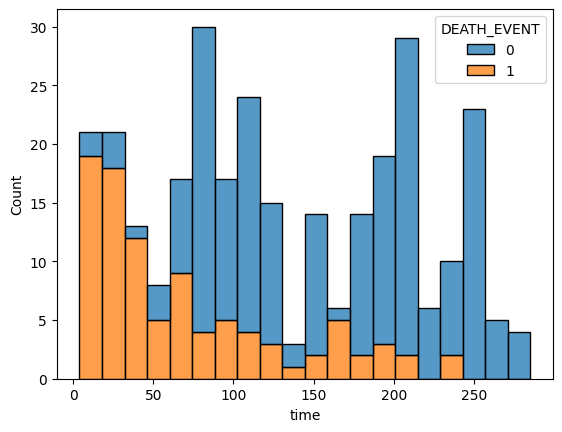

In [19]:
sns.histplot(data=df, x='time', hue='DEATH_EVENT', multiple='stack', bins=20)
plt.show()

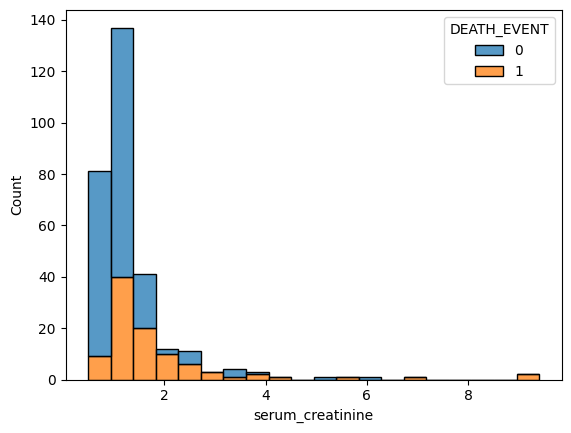

In [20]:
sns.histplot(data=df, x='serum_creatinine', hue='DEATH_EVENT', multiple='stack', bins=20)
plt.show()

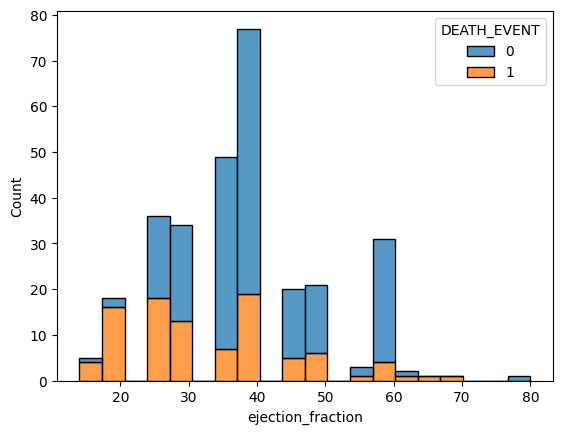

In [21]:
sns.histplot(data=df, x='ejection_fraction', hue='DEATH_EVENT', multiple='stack', bins=20)
plt.show()

In [22]:
Features = ['time','ejection_fraction','serum_creatinine']
x = df[Features]
y = df["DEATH_EVENT"]
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.2, random_state=2)

Accuracy of the model is:  0.9
Recall of the model is:  0.7647058823529411
Precision of the model is:  0.8666666666666667
F1 score of the model is:  0.8125


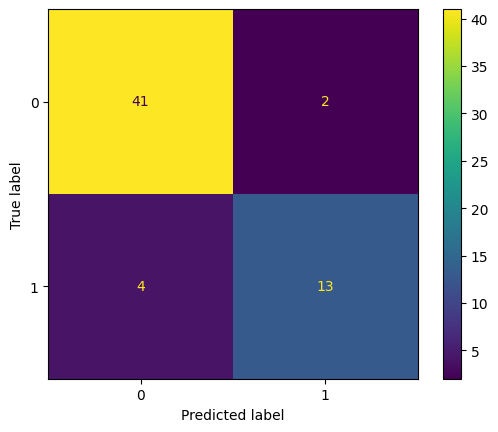

In [23]:
model = LogisticRegression()
model.fit(x_train, y_train)
model_pred = model.predict(x_test)
model_acc = accuracy_score(y_test, model_pred)
cm = confusion_matrix(y_test, model_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
accuracy = accuracy_score(y_test, model_pred)
recall = recall_score(y_test, model_pred)
precision = precision_score(y_test, model_pred)
f1 = f1_score(y_test, model_pred)
print("Accuracy of the model is: ", accuracy)
print("Recall of the model is: ", recall)
print("Precision of the model is: ", precision)
print("F1 score of the model is: ", f1)

Accuracy of the model is:  0.85
Recall of the model is:  0.8235294117647058
Precision of the model is:  0.7
F1 score of the model is:  0.7567567567567568


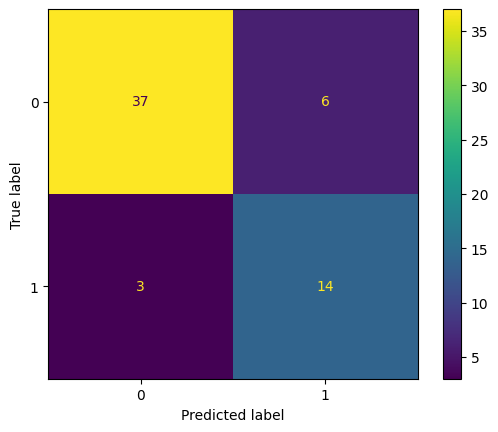

In [24]:
from sklearn.tree import DecisionTreeClassifier
Features = ['time','ejection_fraction','serum_creatinine']
x = df[Features]
y = df["DEATH_EVENT"]
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.2, random_state=2)
model = DecisionTreeClassifier(random_state=42)
model.fit(x_train, y_train)
model_pred = model.predict(x_test)
model_acc = accuracy_score(y_test, model_pred)
cm = confusion_matrix(y_test, model_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
accuracy = accuracy_score(y_test, model_pred)
recall = recall_score(y_test, model_pred)
precision = precision_score(y_test, model_pred)
f1 = f1_score(y_test, model_pred)
print("Accuracy of the model is: ", accuracy)
print("Recall of the model is: ", recall)
print("Precision of the model is: ", precision)
print("F1 score of the model is: ", f1)


Accuracy of the model is:  0.9
Recall of the model is:  0.7647058823529411
Precision of the model is:  0.8666666666666667
F1 score of the model is:  0.8125


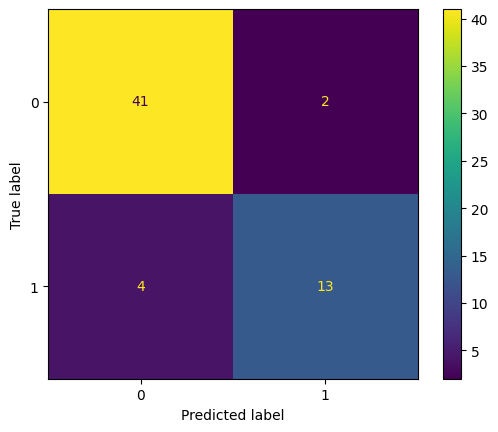

In [25]:
from sklearn.ensemble import RandomForestClassifier
Features = ['time','ejection_fraction','serum_creatinine']
x = df[Features]
y = df["DEATH_EVENT"]
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.2, random_state=2)
model = RandomForestClassifier(random_state=42)
model.fit(x_train, y_train)
model_pred = model.predict(x_test)
model_acc = accuracy_score(y_test, model_pred)
cm = confusion_matrix(y_test, model_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
accuracy = accuracy_score(y_test, model_pred)
recall = recall_score(y_test, model_pred)
precision = precision_score(y_test, model_pred)
f1 = f1_score(y_test, model_pred)
print("Accuracy of the model is: ", accuracy)
print("Recall of the model is: ", recall)
print("Precision of the model is: ", precision)
print("F1 score of the model is: ", f1)


In [26]:
train_pred = model.predict(x_train)

train_accuracy = accuracy_score(y_train, train_pred)
train_recall = recall_score(y_train, train_pred)
train_precision = precision_score(y_train, train_pred)
train_f1 = f1_score(y_train, train_pred)

print("--- Training Metrics ---")
print("Accuracy: ", train_accuracy)
print("Recall:   ", train_recall)
print("Precision:", train_precision)
print("F1 score: ", train_f1)

--- Training Metrics ---
Accuracy:  1.0
Recall:    1.0
Precision: 1.0
F1 score:  1.0


Accuracy of the model is:  0.9333333333333333
Recall of the model is:  0.8235294117647058
Precision of the model is:  0.9333333333333333
F1 score of the model is:  0.875


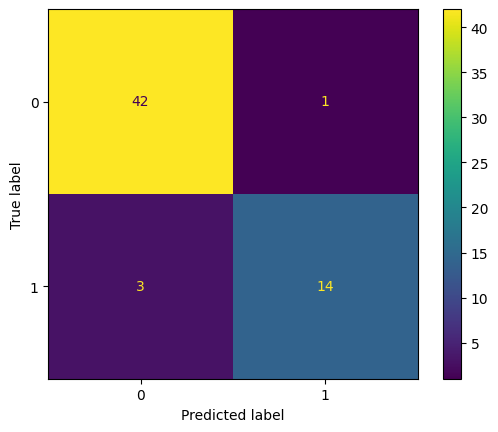

In [27]:
from sklearn.ensemble import RandomForestClassifier
x = df.drop('DEATH_EVENT', axis=1)
y = df["DEATH_EVENT"]
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.2, random_state=2)
model = RandomForestClassifier(random_state=42)
model.fit(x_train, y_train)
model_pred = model.predict(x_test)
model_acc = accuracy_score(y_test, model_pred)
cm = confusion_matrix(y_test, model_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
accuracy = accuracy_score(y_test, model_pred)
recall = recall_score(y_test, model_pred)
precision = precision_score(y_test, model_pred)
f1 = f1_score(y_test, model_pred)
print("Accuracy of the model is: ", accuracy)
print("Recall of the model is: ", recall)
print("Precision of the model is: ", precision)
print("F1 score of the model is: ", f1)


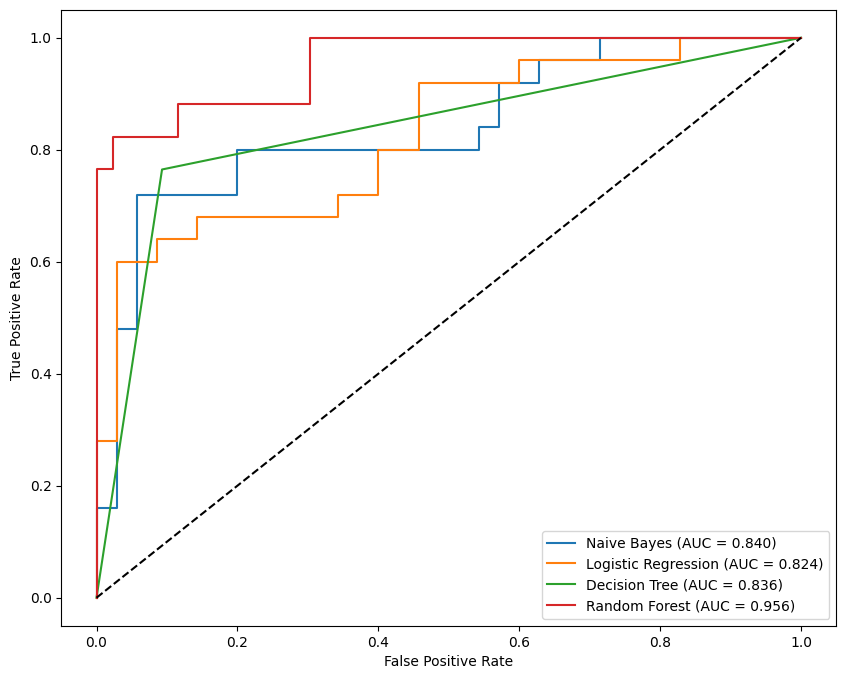

In [29]:
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled_1 = scaler.fit_transform(X_train_1)
X_test_scaled_1 = scaler.transform(X_test_1)

x_train_2, x_test_2, y_train_2, y_test_2 = train_test_split(x, y, test_size=0.2, random_state=2)

nb_probs = naive_bayes.GaussianNB().fit(X_train_1, y_train_1).predict_proba(X_test_1)[:, 1]
lr_probs = LogisticRegression(max_iter=1000).fit(X_train_scaled_1, y_train_1).predict_proba(X_test_scaled_1)[:, 1]
dt_probs = DecisionTreeClassifier(random_state=42).fit(x_train_2, y_train_2).predict_proba(x_test_2)[:, 1]
rf_probs = RandomForestClassifier(random_state=42).fit(x_train_2, y_train_2).predict_proba(x_test_2)[:, 1]

plt.figure(figsize=(10, 8))

models = [
    ("Naive Bayes", y_test_1, nb_probs),
    ("Logistic Regression", y_test_1, lr_probs),
    ("Decision Tree", y_test_2, dt_probs),
    ("Random Forest", y_test_2, rf_probs)
]

for name, y_true, probs in models:
    fpr, tpr, _ = roc_curve(y_true, probs)
    auc = roc_auc_score(y_true, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.show()

In [30]:
import joblib
joblib.dump(model, "model.joblib")

['model.joblib']